# J07 — Infiltration

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 7 : Green–Ampt et Mein–Larson, ajustement Philip/Horton, sols stratifiés et croûte de battance dans HYDRUS-1D*

> Version **instructeur** : code complet et résultats.

## Mise en place

Les fonctions de Mualem–van Genuchten du Jour 5 (`vg_theta`, `vg_K`) et les paramètres de Carsel & Parrish du loam et du sable
sont fournis. Conventions HYDRUS-1D : $z$ positif vers le haut, flux $q > 0$ vers le haut (`vTop` < 0 = infiltration),
profondeurs négatives. Unités : cm et jours (sauf l'exemple du cours et le double anneau, en cm et heures).

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq
from hydrus_io import read_tlevel, read_nod_inf, read_obs_node

HYD = "../../hydrus"

# paramètres de Mualem-van Genuchten (Carsel & Parrish 1988) : theta_r, theta_s, alpha (1/cm), n, Ks (cm/j)
thr_loam = 0.078
ths_loam = 0.430
alpha_loam = 0.036
n_loam = 1.56
Ks_loam = 24.96

thr_sable = 0.045
ths_sable = 0.430
alpha_sable = 0.145
n_sable = 2.68
Ks_sable = 712.8

Ks_loam_sableux = 106.1

# teneur en eau de van Genuchten pour une charge de pression h (cm, négative en sol non saturé)
def vg_theta(h, thr, ths, alpha, n):
    m = 1 - 1 / n
    Se = (1 + (alpha * np.abs(h))**n)**(-m)
    return thr + (ths - thr) * Se

# conductivité hydraulique de Mualem-van Genuchten (cm/j), l = 0,5
def vg_K(h, thr, ths, alpha, n, Ks):
    m = 1 - 1 / n
    Se = (1 + (alpha * np.abs(h))**n)**(-m)
    K = Ks * Se**0.5 * (1 - (1 - Se**(1 / m))**m)**2
    return K

## Exercice 1 — Green–Ampt sous lame d'eau et sous pluie (Mein–Larson)  *(≈ 20 min)*

Loam de Carsel & Parrish ($K_s = 24{,}96$ cm/j), initialement à $h_i = -300$ cm (sous pluie) ou $h_i = -100$ cm (sous lame d'eau).

1. Calculer le déficit d'humidité $\Delta\theta = \theta_s - \theta(h_i)$ et la succion au front $|h_f| = \int_{h_i}^{0} K_r(h)\,dh$
   (intégration numérique avec `np.trapezoid`).
2. Green–Ampt sous lame d'eau $h_0$ : l'infiltration cumulée $I(t)$ est la solution de l'équation implicite
   $I - B\ln(1 + I/B) = K_s t$ avec $B = (h_0 + |h_f|)\Delta\theta$ (`brentq`) ; la capacité d'infiltration vaut $i = K_s(1 + B/I)$.
3. Tracer $I(t)$ et $i(t)$ sous lame d'eau nulle ($h_i = -100$ cm) avec $|h_f| = \int K_r\,dh$ puis $|h_f| = 2$ cm, et les comparer à
   `sum(Infil)` et `vTop` de `J06_infiltration_submergee_loam` (0–0,6 j).
4. Mein & Larson (pluie constante $i_r > K_s$) : $I_p = K_s|h_f|\Delta\theta/(i_r - K_s)$, $t_p = I_p/i_r$ ; $I = i_r t$ avant $t_p$,
   puis $I - I_p - B\ln[(B + I)/(B + I_p)] = K_s(t - t_p)$. Refaire l'exemple du cours : pluie de 30 mm/h pendant 2 h sur le loam
   ($K_s = 1{,}04$ cm/h, $\Delta\theta = 0{,}26$, $|h_f| = 6{,}9$ cm) : $t_p$ (≈ 19 min), infiltration et ruissellement à 1 h et 2 h.
5. Pluie de 30 cm/j sur le loam à $h_i = -300$ cm : comparer $t_p$, $I_p$ et $I(t)$ à `J06_pluie_flux_impose_loam` ($t_p \approx 0{,}088$ j).
6. Déterminer le $|h_f|$ « effectif » qui reproduit le $t_p$ de HYDRUS (inverser la formule de $t_p$) et la sorptivité équivalente
   $S = \sqrt{2 K_s |h_f| \Delta\theta}$ ; commenter.

**1. Paramètres du loam : Δθ et |h_f|**

In [2]:
h_i_pluie = -300.0    # charge de pression initiale sous pluie (cm)
h_i_lame = -100.0     # charge de pression initiale sous lame d'eau (cm)

# déficit d'humidité initial : theta_s - theta(h_i)
dtheta_300 = ths_loam - vg_theta(h_i_pluie, thr_loam, ths_loam, alpha_loam, n_loam)
dtheta_100 = ths_loam - vg_theta(h_i_lame, thr_loam, ths_loam, alpha_loam, n_loam)

# succion au front |h_f| = intégrale de K_r(h) = K(h) / Ks entre h_i et 0 (au-delà de -1000 cm, K_r est négligeable)
h_grid = np.linspace(-1000, 0, 10001)
Kr_grid = vg_K(h_grid, thr_loam, ths_loam, alpha_loam, n_loam, Ks_loam) / Ks_loam
hf_loam = np.trapezoid(Kr_grid, h_grid)

print(f"loam : |h_f| = {hf_loam:.2f} cm, dtheta(h_i = -300) = {dtheta_300:.3f}, dtheta(h_i = -100) = {dtheta_100:.3f}")

loam : |h_f| = 6.92 cm, dtheta(h_i = -300) = 0.260, dtheta(h_i = -100) = 0.188


**2. Green–Ampt sous lame d'eau : résolution implicite**

In [3]:
# équation implicite de Green-Ampt : vaut 0 quand I est l'infiltration cumulée au temps t
def equation_green_ampt(I, t, Ks, B):
    return I - B * np.log(1 + I / B) - Ks * t

# infiltration cumulée I(t) (cm) sous une lame d'eau h0 : brentq cherche la racine de l'équation entre 0 et une borne large
def green_ampt_cumul(t, Ks, hf, dtheta, h0):
    B = (hf + h0) * dtheta
    if t <= 0:
        return 0.0
    I = brentq(equation_green_ampt, 1e-9, Ks * t + 50 * B + 1, args=(t, Ks, B))
    return I

# capacité d'infiltration i (cm/j) quand le cumul vaut I
def green_ampt_taux(I, Ks, hf, dtheta, h0):
    B = (hf + h0) * dtheta
    return Ks * (1 + B / I)

# test : loam sous lame d'eau nulle, h_i = -100 cm, après 0,1 j
I_test = green_ampt_cumul(0.1, Ks_loam, hf_loam, dtheta_100, 0.0)
i_test = green_ampt_taux(I_test, Ks_loam, hf_loam, dtheta_100, 0.0)
print(f"I(0,1 j) = {I_test:.2f} cm, i(0,1 j) = {i_test:.1f} cm/j")

I(0,1 j) = 4.42 cm, i(0,1 j) = 32.3 cm/j


**3a. Lame d'eau nulle, h_i = −100 cm : infiltration cumulée, comparaison à HYDRUS**

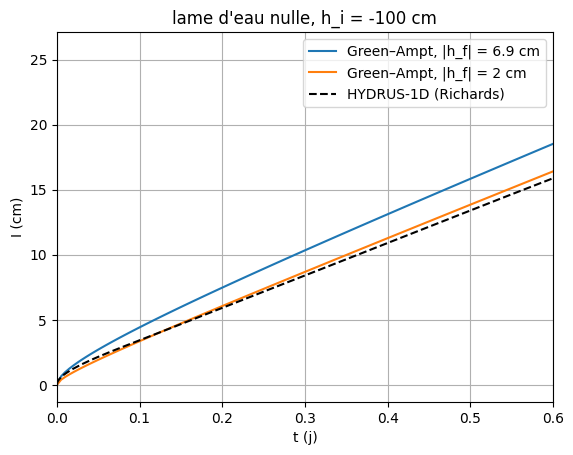

I(0,6 j) : Green–Ampt |h_f| = 6.9 cm : 18.5 cm, |h_f| = 2 cm : 16.4 cm, HYDRUS : 15.9 cm


In [4]:
tl_lame = read_tlevel(f"{HYD}/J06_infiltration_submergee_loam")

# I(t) de Green-Ampt avec |h_f| = int Kr dh, puis avec |h_f| = 2 cm
t_lame = np.linspace(0, 0.6, 121)
I_hf69 = np.zeros(len(t_lame))
I_hf2 = np.zeros(len(t_lame))
for k in range(len(t_lame)):
    I_hf69[k] = green_ampt_cumul(t_lame[k], Ks_loam, hf_loam, dtheta_100, 0.0)
    I_hf2[k] = green_ampt_cumul(t_lame[k], Ks_loam, 2.0, dtheta_100, 0.0)

plt.figure()
plt.plot(t_lame, I_hf69, "-", label=f"Green–Ampt, |h_f| = {hf_loam:.1f} cm")
plt.plot(t_lame, I_hf2, "-", label="Green–Ampt, |h_f| = 2 cm")
plt.plot(tl_lame.index, tl_lame["sum(Infil)"], "k--", label="HYDRUS-1D (Richards)")
plt.xlim(0, 0.6)
plt.xlabel("t (j)")
plt.ylabel("I (cm)")
plt.title("lame d'eau nulle, h_i = -100 cm")
plt.legend()
plt.grid(True)
plt.show()

I_hyd_06 = np.interp(0.6, tl_lame.index, tl_lame["sum(Infil)"])
print(f"I(0,6 j) : Green–Ampt |h_f| = {hf_loam:.1f} cm : {I_hf69[-1]:.1f} cm, |h_f| = 2 cm : {I_hf2[-1]:.1f} cm, HYDRUS : {I_hyd_06:.1f} cm")

**3b. Taux d'infiltration sous lame d'eau**

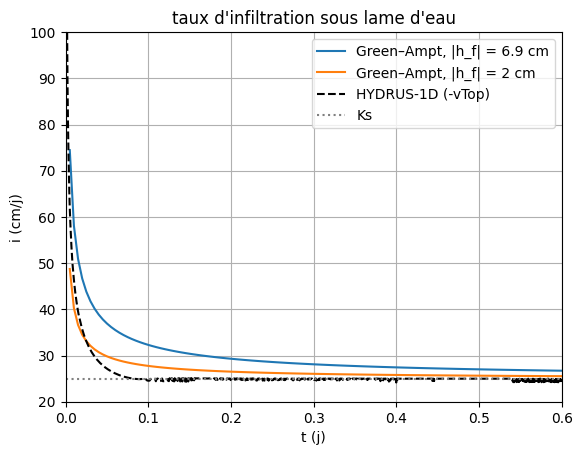

In [5]:
# capacité d'infiltration à partir du cumul (on saute t = 0 où I = 0)
i_hf69 = green_ampt_taux(I_hf69[1:], Ks_loam, hf_loam, dtheta_100, 0.0)
i_hf2 = green_ampt_taux(I_hf2[1:], Ks_loam, 2.0, dtheta_100, 0.0)

plt.figure()
plt.plot(t_lame[1:], i_hf69, "-", label=f"Green–Ampt, |h_f| = {hf_loam:.1f} cm")
plt.plot(t_lame[1:], i_hf2, "-", label="Green–Ampt, |h_f| = 2 cm")
plt.plot(tl_lame.index, -tl_lame["vTop"], "k--", label="HYDRUS-1D (-vTop)")
plt.axhline(Ks_loam, color="gray", linestyle=":", label="Ks")
plt.xlim(0, 0.6)
plt.ylim(20, 100)
plt.xlabel("t (j)")
plt.ylabel("i (cm/j)")
plt.title("taux d'infiltration sous lame d'eau")
plt.legend()
plt.grid(True)
plt.show()

**4. Mein–Larson : exemple du cours (pluie de 30 mm/h pendant 2 h)**

In [6]:
# temps de submersion t_p (même unité de temps que Ks) sous une pluie constante i_r > Ks (Mein & Larson 1973)
def temps_submersion(i_r, Ks, hf, dtheta):
    I_p = Ks * hf * dtheta / (i_r - Ks)
    t_p = I_p / i_r
    return t_p

# équation implicite après la submersion : courbe de Green-Ampt décalée de (t_p, I_p)
def equation_mein_larson(I, t, Ks, B, I_p, t_p):
    return I - I_p - B * np.log((B + I) / (B + I_p)) - Ks * (t - t_p)

# infiltration cumulée I(t) sous pluie constante i_r : I = i_r t avant t_p, racine de l'équation décalée après
def green_ampt_pluie(t, i_r, Ks, hf, dtheta):
    B = hf * dtheta
    t_p = temps_submersion(i_r, Ks, hf, dtheta)
    I_p = i_r * t_p
    if t <= t_p:
        return i_r * t
    I = brentq(equation_mein_larson, I_p, I_p + i_r * (t - t_p) + 1e-9, args=(t, Ks, B, I_p, t_p))
    return I

# exemple du cours, en cm et heures : loam Ks = 1,04 cm/h, dtheta = 0,26, |h_f| = 6,9 cm, pluie i_r = 3 cm/h
Ks_h = 1.04
t_p_cours = temps_submersion(3.0, Ks_h, 6.9, 0.26)
print(f"t_p = {t_p_cours:.3f} h = {t_p_cours * 60:.0f} min, I_p = {3.0 * t_p_cours:.3f} cm")
for t_h in [1.0, 2.0]:
    I_h = green_ampt_pluie(t_h, 3.0, Ks_h, 6.9, 0.26)
    ruissellement = 3.0 * t_h - I_h
    print(f"t = {t_h:.0f} h : I = {I_h:.2f} cm, ruissellement = {ruissellement:.2f} cm ({100 * ruissellement / (3.0 * t_h):.0f} % de la pluie)")

t_p = 0.317 h = 19 min, I_p = 0.952 cm
t = 1 h : I = 2.44 cm, ruissellement = 0.56 cm (19 % de la pluie)
t = 2 h : I = 4.06 cm, ruissellement = 1.94 cm (32 % de la pluie)


**5. Pluie de 30 cm/j, h_i = −300 cm : comparaison à HYDRUS**

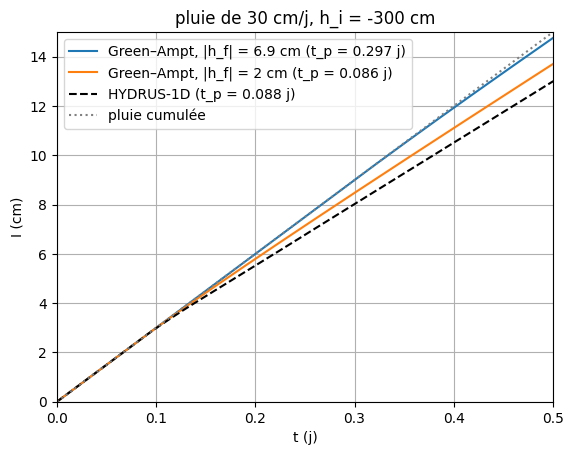

Green–Ampt avec |h_f| = 6.92 cm : t_p = 0.297 j (7.1 h), I_p = 8.91 cm
HYDRUS-1D : t_p = 0.0880 j (2.1 h), I_p = 2.64 cm


In [7]:
tl_pluie = read_tlevel(f"{HYD}/J06_pluie_flux_impose_loam")
i_r = 30.0    # intensité de la pluie (cm/j)

# submersion dans HYDRUS : premier instant où hTop atteint 0
submersion = tl_pluie[tl_pluie["hTop"] >= -1e-6]
t_p_hyd = submersion.index[0]
I_p_hyd = submersion["sum(Infil)"].iloc[0]

# Green-Ampt avec |h_f| = int Kr dh et avec |h_f| = 2 cm
t_p_69 = temps_submersion(i_r, Ks_loam, hf_loam, dtheta_300)
t_p_2 = temps_submersion(i_r, Ks_loam, 2.0, dtheta_300)
t_pluie = np.linspace(0, 0.5, 201)
I_pluie_69 = np.zeros(len(t_pluie))
I_pluie_2 = np.zeros(len(t_pluie))
for k in range(len(t_pluie)):
    I_pluie_69[k] = green_ampt_pluie(t_pluie[k], i_r, Ks_loam, hf_loam, dtheta_300)
    I_pluie_2[k] = green_ampt_pluie(t_pluie[k], i_r, Ks_loam, 2.0, dtheta_300)

plt.figure()
plt.plot(t_pluie, I_pluie_69, "-", label=f"Green–Ampt, |h_f| = {hf_loam:.1f} cm (t_p = {t_p_69:.3f} j)")
plt.plot(t_pluie, I_pluie_2, "-", label=f"Green–Ampt, |h_f| = 2 cm (t_p = {t_p_2:.3f} j)")
plt.plot(tl_pluie.index, tl_pluie["sum(Infil)"], "k--", label=f"HYDRUS-1D (t_p = {t_p_hyd:.3f} j)")
plt.plot(t_pluie, i_r * t_pluie, ":", color="gray", label="pluie cumulée")
plt.xlim(0, 0.5)
plt.ylim(0, 15)
plt.xlabel("t (j)")
plt.ylabel("I (cm)")
plt.title("pluie de 30 cm/j, h_i = -300 cm")
plt.legend()
plt.grid(True)
plt.show()

print(f"Green–Ampt avec |h_f| = {hf_loam:.2f} cm : t_p = {t_p_69:.3f} j ({t_p_69 * 24:.1f} h), I_p = {i_r * t_p_69:.2f} cm")
print(f"HYDRUS-1D : t_p = {t_p_hyd:.4f} j ({t_p_hyd * 24:.1f} h), I_p = {I_p_hyd:.2f} cm")

**6. |h_f| effectif et sorptivité équivalente**

In [8]:
# inversion de t_p = Ks |h_f| dtheta / (i_r (i_r - Ks)) : le |h_f| qui donne le t_p de HYDRUS
hf_eff = t_p_hyd * i_r * (i_r - Ks_loam) / (Ks_loam * dtheta_300)

# sorptivité équivalente de Green-Ampt : S = sqrt(2 Ks |h_f| dtheta)
S_69 = np.sqrt(2 * Ks_loam * hf_loam * dtheta_300)
S_eff = np.sqrt(2 * Ks_loam * hf_eff * dtheta_300)

print(f"|h_f| effectif reproduisant t_p = {t_p_hyd:.3f} j : {hf_eff:.2f} cm")
print(f"sorptivité équivalente : {S_69:.2f} cm/j^0.5 (|h_f| = int Kr dh), {S_eff:.2f} cm/j^0.5 (|h_f| effectif)")

|h_f| effectif reproduisant t_p = 0.088 j : 2.05 cm
sorptivité équivalente : 9.48 cm/j^0.5 (|h_f| = int Kr dh), 5.16 cm/j^0.5 (|h_f| effectif)


**Commentaire (instructeur).** Sous lame d'eau, Green–Ampt avec $|h_f| = \int K_r\,dh = 6{,}9$ cm surestime le cumul de 15 % par rapport à Richards ; sous pluie
de 30 cm/j (seulement 1,2 $K_s$), il retarde la submersion d'un facteur 3 (0,30 j contre 0,088 j). Le $|h_f|$ effectif est de 2 cm :
le front du loam de van Genuchten ($n = 1{,}56$) est diffus et la capacité d'infiltration retombe vers $K_s$ bien plus vite que
ne le prévoit le piston. Green–Ampt est un modèle de sol grossier ; pour les sols fins, $h_f$ doit être calé, d'autant plus que
$i_r/K_s$ est proche de 1 ($t_p \propto 1/(i_r - K_s)$). L'exemple du cours (30 mm/h, $t_p$ = 19 min, 32 % de ruissellement à 2 h)
montre qu'à forte intensité le résultat est beaucoup moins sensible à $h_f$.

## Exercice 2 — Essai au double anneau : Philip et Horton  *(≈ 15 min)*

`data/J07_double_anneau.csv` : infiltration cumulée $I$ (cm) mesurée pendant 3 h sur deux sites (A : loam ; B : loam sableux structuré).
Temps en heures dans tout l'exercice.

1. Écrire les deux modèles : Philip $I = S\sqrt{t} + At$ et Horton $I = i_f t + (i_0 - i_f)(1 - e^{-kt})/k$.
2. Ajuster chaque modèle sur chaque site avec `curve_fit` ; donner les paramètres et la RMSE.
3. Tracer $I(t)$ mesuré et ajusté, puis $i(t)$ des deux modèles jusqu'à 6 h (extrapolation) ; comparer $A$ et $i_f$.
4. Estimer $K_s$ ($\approx A/0{,}4$ et $\approx i_f$), le temps gravitaire $t_{grav} = (S/K_s)^2$ et la longueur capillaire
   $\lambda_c = b S^2/(\Delta\theta K_s)$ (White & Sully, $b = 0{,}55$, $\Delta\theta = 0{,}25$) ; comparer aux valeurs de Carsel & Parrish.

**Lecture des données**

In [9]:
da = pd.read_csv("data/J07_double_anneau.csv")
print(da.head())

# site A (loam) et site B (loam sableux structuré) : temps en heures, cumul en cm
site_A = da[da["site"] == "A"]
site_B = da[da["site"] == "B"]
t_A = site_A["t_min"].to_numpy() / 60.0
I_A = site_A["I_cm"].to_numpy()
t_B = site_B["t_min"].to_numpy() / 60.0
I_B = site_B["I_cm"].to_numpy()
print("nombre de mesures :", len(t_A), "par site, de", t_A[0] * 60, "à", t_A[-1] * 60, "min")

  site texture  t_min  I_cm
0    A    loam      1  0.25
1    A    loam      2  0.35
2    A    loam      3  0.48
3    A    loam      5  0.61
4    A    loam      7  0.74
nombre de mesures : 15 par site, de 1.0 à 180.0 min


**1. Modèles de Philip et de Horton**

In [10]:
# infiltration cumulée de Philip (t en h, S en cm/h^0.5, A en cm/h)
def philip(t, S, A):
    return S * np.sqrt(t) + A * t

# infiltration cumulée de Horton (i0 et i_f en cm/h, k en 1/h)
def horton(t, i0, i_f, k):
    return i_f * t + (i0 - i_f) * (1 - np.exp(-k * t)) / k

print("Philip, S = 1,8, A = 1,2 : I(1 h) =", round(philip(1.0, 1.8, 1.2), 2), "cm")
print("Horton, i0 = 8, i_f = 2, k = 6 : I(1 h) =", round(horton(1.0, 8.0, 2.0, 6.0), 2), "cm")

Philip, S = 1,8, A = 1,2 : I(1 h) = 3.0 cm
Horton, i0 = 8, i_f = 2, k = 6 : I(1 h) = 3.0 cm


**2a. Ajustement sur le site A**

In [11]:
# Philip : curve_fit retourne les paramètres optimaux (popt) et leur covariance (pcov)
popt, pcov = curve_fit(philip, t_A, I_A, p0=[1, 1])
S_A = popt[0]
A_A = popt[1]
rmse_philip_A = np.sqrt(np.mean((I_A - philip(t_A, S_A, A_A))**2))

# Horton : trois paramètres, bornés entre 0 et des valeurs plausibles
popt, pcov = curve_fit(horton, t_A, I_A, p0=[5, 1, 2], bounds=(0, [50, 20, 50]))
i0_A = popt[0]
if_A = popt[1]
k_A = popt[2]
rmse_horton_A = np.sqrt(np.mean((I_A - horton(t_A, i0_A, if_A, k_A))**2))

print(f"site A (loam) : Philip S = {S_A:.3f} cm/h^0.5, A = {A_A:.3f} cm/h, RMSE = {rmse_philip_A:.3f} cm")
print(f"site A (loam) : Horton i0 = {i0_A:.2f} cm/h, i_f = {if_A:.3f} cm/h, k = {k_A:.2f} 1/h, RMSE = {rmse_horton_A:.3f} cm")

site A (loam) : Philip S = 1.760 cm/h^0.5, A = 1.252 cm/h, RMSE = 0.043 cm
site A (loam) : Horton i0 = 8.28 cm/h, i_f = 1.976 cm/h, k = 6.48 1/h, RMSE = 0.088 cm


**2b. Ajustement sur le site B**

In [12]:
popt, pcov = curve_fit(philip, t_B, I_B, p0=[1, 1])
S_B = popt[0]
A_B = popt[1]
rmse_philip_B = np.sqrt(np.mean((I_B - philip(t_B, S_B, A_B))**2))

popt, pcov = curve_fit(horton, t_B, I_B, p0=[5, 1, 2], bounds=(0, [50, 20, 50]))
i0_B = popt[0]
if_B = popt[1]
k_B = popt[2]
rmse_horton_B = np.sqrt(np.mean((I_B - horton(t_B, i0_B, if_B, k_B))**2))

print(f"site B (loam sableux) : Philip S = {S_B:.3f} cm/h^0.5, A = {A_B:.3f} cm/h, RMSE = {rmse_philip_B:.3f} cm")
print(f"site B (loam sableux) : Horton i0 = {i0_B:.2f} cm/h, i_f = {if_B:.3f} cm/h, k = {k_B:.2f} 1/h, RMSE = {rmse_horton_B:.3f} cm")

site B (loam sableux) : Philip S = 4.325 cm/h^0.5, A = 4.180 cm/h, RMSE = 0.149 cm
site B (loam sableux) : Horton i0 = 23.69 cm/h, i_f = 6.018 cm/h, k = 7.81 1/h, RMSE = 0.214 cm


**3a. Infiltration cumulée mesurée et ajustée (extrapolation à 6 h)**

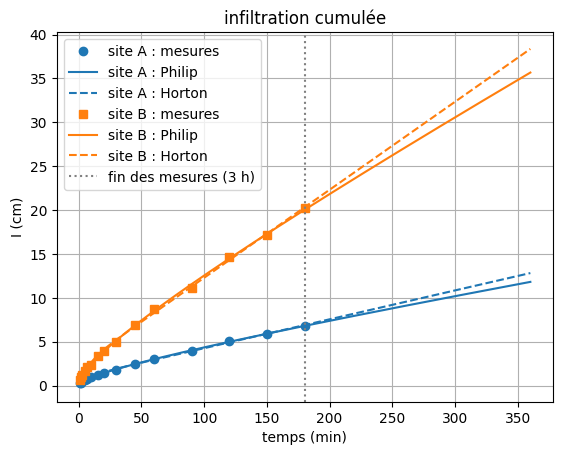

In [13]:
tt = np.linspace(0.01, 6, 400)    # heures

plt.figure()
plt.plot(t_A * 60, I_A, "o", color="C0", label="site A : mesures")
plt.plot(tt * 60, philip(tt, S_A, A_A), "-", color="C0", label="site A : Philip")
plt.plot(tt * 60, horton(tt, i0_A, if_A, k_A), "--", color="C0", label="site A : Horton")
plt.plot(t_B * 60, I_B, "s", color="C1", label="site B : mesures")
plt.plot(tt * 60, philip(tt, S_B, A_B), "-", color="C1", label="site B : Philip")
plt.plot(tt * 60, horton(tt, i0_B, if_B, k_B), "--", color="C1", label="site B : Horton")
plt.axvline(180, color="gray", linestyle=":", label="fin des mesures (3 h)")
plt.xlabel("temps (min)")
plt.ylabel("I (cm)")
plt.title("infiltration cumulée")
plt.legend()
plt.grid(True)
plt.show()

**3b. Taux d'infiltration des deux modèles**

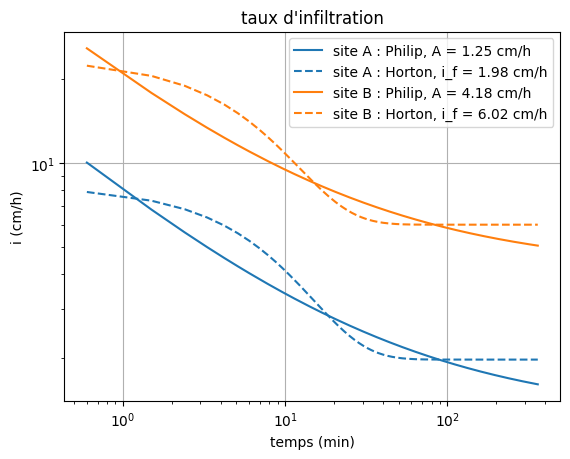

In [14]:
# i(t) = dérivée de I(t) : Philip i = S / (2 sqrt(t)) + A, Horton i = i_f + (i0 - i_f) exp(-k t)
i_philip_A = S_A / (2 * np.sqrt(tt)) + A_A
i_horton_A = if_A + (i0_A - if_A) * np.exp(-k_A * tt)
i_philip_B = S_B / (2 * np.sqrt(tt)) + A_B
i_horton_B = if_B + (i0_B - if_B) * np.exp(-k_B * tt)

plt.figure()
plt.loglog(tt * 60, i_philip_A, "-", color="C0", label=f"site A : Philip, A = {A_A:.2f} cm/h")
plt.loglog(tt * 60, i_horton_A, "--", color="C0", label=f"site A : Horton, i_f = {if_A:.2f} cm/h")
plt.loglog(tt * 60, i_philip_B, "-", color="C1", label=f"site B : Philip, A = {A_B:.2f} cm/h")
plt.loglog(tt * 60, i_horton_B, "--", color="C1", label=f"site B : Horton, i_f = {if_B:.2f} cm/h")
plt.xlabel("temps (min)")
plt.ylabel("i (cm/h)")
plt.title("taux d'infiltration")
plt.legend()
plt.grid(True)
plt.show()

**4. Estimation de Ks, du temps gravitaire et de la longueur capillaire**

In [15]:
b = 0.55
dtheta_anneau = 0.25

# site A : Ks d'après A (Philip) et d'après i_f (Horton), temps gravitaire, longueur capillaire
Ks_A_philip = A_A / 0.4
Ks_A_horton = if_A
t_grav_A = (S_A / Ks_A_philip)**2
lambda_c_A = b * S_A**2 / (dtheta_anneau * Ks_A_philip)

# site B
Ks_B_philip = A_B / 0.4
Ks_B_horton = if_B
t_grav_B = (S_B / Ks_B_philip)**2
lambda_c_B = b * S_B**2 / (dtheta_anneau * Ks_B_philip)

tableau = pd.DataFrame({
    "site": ["A (loam)", "B (loam sableux)"],
    "Ks_A/0.4_cm_h": [Ks_A_philip, Ks_B_philip],
    "Ks_if_cm_h": [Ks_A_horton, Ks_B_horton],
    "Ks_CarselParrish_cm_h": [Ks_loam / 24, Ks_loam_sableux / 24],
    "t_grav_h": [t_grav_A, t_grav_B],
    "lambda_c_cm": [lambda_c_A, lambda_c_B],
})
print(tableau.round(3))

               site  Ks_A/0.4_cm_h  Ks_if_cm_h  Ks_CarselParrish_cm_h  \
0          A (loam)           3.13       1.976                  1.040   
1  B (loam sableux)          10.45       6.018                  4.421   

   t_grav_h  lambda_c_cm  
0     0.316        2.176  
1     0.171        3.938  


**Commentaire (instructeur).** Les deux modèles reproduisent les mesures à 0,05–0,2 cm près (bruit de 2 %) mais divergent en extrapolation : après 3 h, Philip
tend vers $A$ et Horton vers $i_f$, qui diffèrent de 40 à 60 %. Le site B (loam sableux structuré) a une sorptivité 2,5 fois
plus grande et un $K_s$ apparent 3 fois plus grand que le site A : en surface, les macropores dominent, et $K_s$ estimé au double
anneau dépasse la valeur de catalogue de la matrice. $t_{grav}$ (0,3 h sur A, 0,2 h sur B) rappelle que la série de Philip
tronquée ne décrit que le début de l'essai.

## Exercice 3 — Sols stratifiés dans HYDRUS-1D : loam sur sable, sable sur loam  *(≈ 15 min)*

Projets `J07_stratifie_loam_sur_sable` et `J07_stratifie_sable_sur_loam` : deux couches (0–30 cm / 30–100 cm), $h_i = -200$ cm,
lame d'eau nulle en surface, drainage libre, 1 j, nœuds d'observation à 10, 25, 35 et 60 cm (nœuds 11, 26, 36, 61).

1. Tracer les profils $\theta(z)$ (`read_nod_inf`) à 0,1 ; 0,25 ; 0,5 ; 1 j pour les deux projets, puis les profils $h(z)$ à 0,25 et 1 j.
2. Tracer `vTop`$(t)$ et `sum(Infil)`$(t)$ (`read_tlevel`) ; donner $I(1\,\mathrm{j})$ (attendu : 26,1 cm contre 45,1 cm) et les flux
   en surface et au bas à 1 j.
3. Position du front en fonction du temps (premier nœud, en partant de la surface, où $\theta < \theta_i + 0{,}02$) pour chaque temps
   d'impression ; identifier l'arrêt à l'interface.
4. `read_obs_node` : $h(t)$ aux quatre nœuds d'observation du cas loam sur sable ; vérifier que le sable ne transmet le flux qu'une fois
   $h$ à l'interface remonté à $\approx -9$ cm (résoudre $K_{sable}(h^*) = K_{s,loam}$ avec `brentq`) et que $\theta_{sable}$ vaut alors $\approx 0{,}235$.

**Lecture des sorties HYDRUS**

In [16]:
P_LS = f"{HYD}/J07_stratifie_loam_sur_sable"
P_SL = f"{HYD}/J07_stratifie_sable_sur_loam"
nod_LS = read_nod_inf(P_LS)     # dictionnaire {temps d'impression: DataFrame des nœuds}
nod_SL = read_nod_inf(P_SL)
tl_LS = read_tlevel(P_LS)       # DataFrame indexé par le temps (T_LEVEL.OUT)
tl_SL = read_tlevel(P_SL)

z = nod_LS[0.0]["Depth"].to_numpy()                 # profondeurs (cm, négatives), 101 nœuds
theta_i_LS = nod_LS[0.0]["Moisture"].to_numpy()     # profils initiaux
theta_i_SL = nod_SL[0.0]["Moisture"].to_numpy()
print("temps d'impression (j) :", sorted(nod_LS.keys()))
print(nod_LS[0.25][["Depth", "Head", "Moisture", "K", "Flux"]].iloc[28:36])

temps d'impression (j) : [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
      Depth     Head  Moisture          K     Flux
Node                                              
29    -28.0   -4.812    0.4221   9.931000 -24.7800
30    -29.0   -6.573    0.4175   7.998000 -24.7300
31    -30.0   -9.118    0.4101   5.944000 -24.7000
32    -31.0  -10.984    0.1972  11.290000 -23.1900
33    -32.0  -12.575    0.1720   5.456000 -19.2100
34    -33.0  -16.526    0.1307   1.301000 -12.8600
35    -34.0  -28.889    0.0798   0.045290  -5.3640
36    -35.0 -104.399    0.0491   0.000017  -0.8671


**1a. Profils θ(z), loam sur sable**

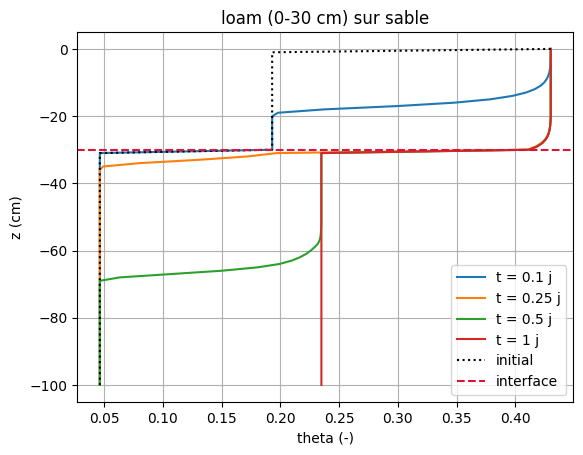

In [17]:
plt.figure()
for t in [0.1, 0.25, 0.5, 1.0]:
    plt.plot(nod_LS[t]["Moisture"], nod_LS[t]["Depth"], "-", label=f"t = {t:g} j")
plt.plot(theta_i_LS, z, "k:", label="initial")
plt.axhline(-30, color="crimson", linestyle="--", label="interface")
plt.xlabel("theta (-)")
plt.ylabel("z (cm)")
plt.title("loam (0-30 cm) sur sable")
plt.legend()
plt.grid(True)
plt.show()

**1b. Profils θ(z), sable sur loam**

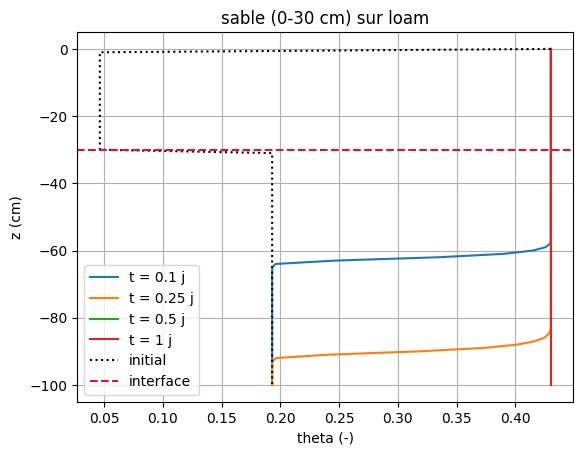

In [18]:
plt.figure()
for t in [0.1, 0.25, 0.5, 1.0]:
    plt.plot(nod_SL[t]["Moisture"], nod_SL[t]["Depth"], "-", label=f"t = {t:g} j")
plt.plot(theta_i_SL, z, "k:", label="initial")
plt.axhline(-30, color="crimson", linestyle="--", label="interface")
plt.xlabel("theta (-)")
plt.ylabel("z (cm)")
plt.title("sable (0-30 cm) sur loam")
plt.legend()
plt.grid(True)
plt.show()

**1c. Profils h(z) à 0,25 et 1 j**

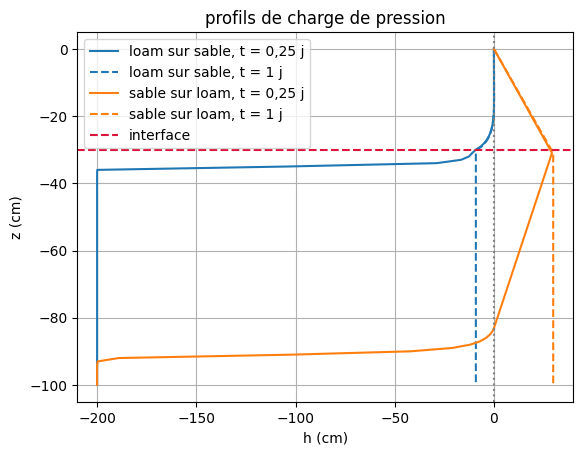

h à l'interface (z = -30 cm) à 1 j : loam sur sable -8.5 cm, sable sur loam 28.9 cm


In [19]:
plt.figure()
plt.plot(nod_LS[0.25]["Head"], nod_LS[0.25]["Depth"], "-", color="C0", label="loam sur sable, t = 0,25 j")
plt.plot(nod_LS[1.0]["Head"], nod_LS[1.0]["Depth"], "--", color="C0", label="loam sur sable, t = 1 j")
plt.plot(nod_SL[0.25]["Head"], nod_SL[0.25]["Depth"], "-", color="C1", label="sable sur loam, t = 0,25 j")
plt.plot(nod_SL[1.0]["Head"], nod_SL[1.0]["Depth"], "--", color="C1", label="sable sur loam, t = 1 j")
plt.axhline(-30, color="crimson", linestyle="--", label="interface")
plt.axvline(0, color="gray", linestyle=":")
plt.xlim(-210, 40)
plt.xlabel("h (cm)")
plt.ylabel("z (cm)")
plt.title("profils de charge de pression")
plt.legend()
plt.grid(True)
plt.show()

h_interface_LS = nod_LS[1.0]["Head"].iloc[30]     # nœud 31 : z = -30 cm
h_interface_SL = nod_SL[1.0]["Head"].iloc[30]
print(f"h à l'interface (z = -30 cm) à 1 j : loam sur sable {h_interface_LS:.1f} cm, sable sur loam {h_interface_SL:.1f} cm")

**2a. Taux d'infiltration −vTop(t)**

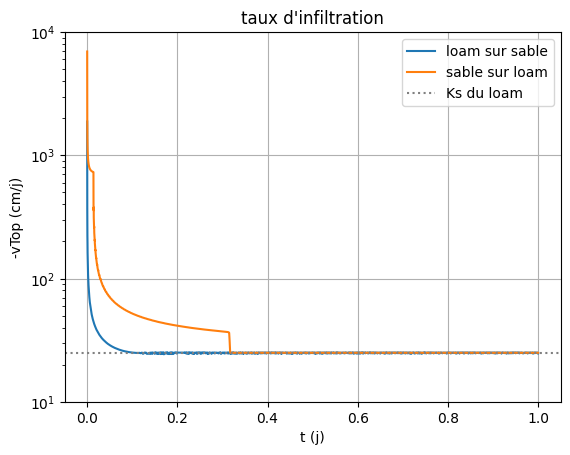

In [20]:
plt.figure()
plt.semilogy(tl_LS.index, -tl_LS["vTop"], "-", label="loam sur sable")
plt.semilogy(tl_SL.index, -tl_SL["vTop"], "-", label="sable sur loam")
plt.axhline(Ks_loam, color="gray", linestyle=":", label="Ks du loam")
plt.ylim(10, 1e4)
plt.xlabel("t (j)")
plt.ylabel("-vTop (cm/j)")
plt.title("taux d'infiltration")
plt.legend()
plt.grid(True)
plt.show()

**2b. Infiltration cumulée et flux à 1 j**

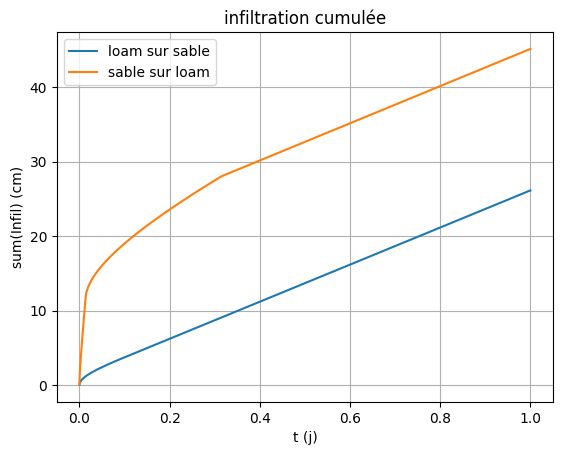

loam sur sable : I(1 j) = 26.1 cm, vTop = -24.7 cm/j, vBot = -24.9 cm/j, variation de stock = 20.1 cm
sable sur loam : I(1 j) = 45.1 cm, vTop = -25.0 cm/j, vBot = -25.0 cm/j, variation de stock = 27.9 cm


In [21]:
plt.figure()
plt.plot(tl_LS.index, tl_LS["sum(Infil)"], "-", label="loam sur sable")
plt.plot(tl_SL.index, tl_SL["sum(Infil)"], "-", label="sable sur loam")
plt.xlabel("t (j)")
plt.ylabel("sum(Infil) (cm)")
plt.title("infiltration cumulée")
plt.legend()
plt.grid(True)
plt.show()

# valeurs finales (dernière ligne de T_LEVEL.OUT, t = 1 j)
I_LS = tl_LS["sum(Infil)"].iloc[-1]
I_SL = tl_SL["sum(Infil)"].iloc[-1]
vTop_LS = tl_LS["vTop"].iloc[-1]
vTop_SL = tl_SL["vTop"].iloc[-1]
vBot_LS = tl_LS["vBot"].iloc[-1]
vBot_SL = tl_SL["vBot"].iloc[-1]
stock_LS = tl_LS["Volume"].iloc[-1] - tl_LS["Volume"].iloc[0]
stock_SL = tl_SL["Volume"].iloc[-1] - tl_SL["Volume"].iloc[0]
print(f"loam sur sable : I(1 j) = {I_LS:.1f} cm, vTop = {vTop_LS:.1f} cm/j, vBot = {vBot_LS:.1f} cm/j, variation de stock = {stock_LS:.1f} cm")
print(f"sable sur loam : I(1 j) = {I_SL:.1f} cm, vTop = {vTop_SL:.1f} cm/j, vBot = {vBot_SL:.1f} cm/j, variation de stock = {stock_SL:.1f} cm")

**3. Position du front en fonction du temps**

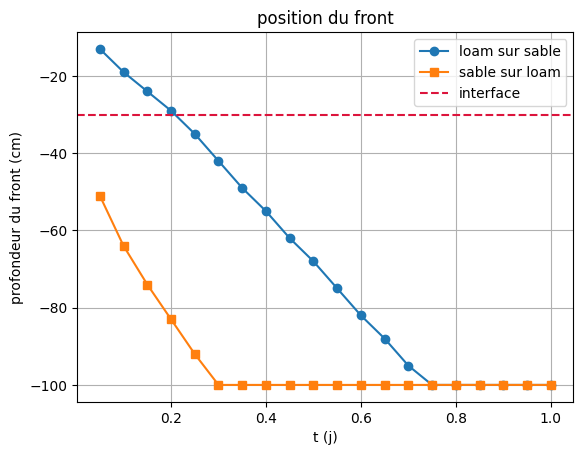

    t_j  z_front_loam_sur_sable  z_front_sable_sur_loam
0  0.05                   -13.0                   -51.0
1  0.10                   -19.0                   -64.0
2  0.15                   -24.0                   -74.0
3  0.20                   -29.0                   -83.0
4  0.25                   -35.0                   -92.0
5  0.30                   -42.0                  -100.0
6  0.35                   -49.0                  -100.0
7  0.40                   -55.0                  -100.0


In [22]:
# profondeur du front : premier nœud (en partant de la surface, nœud de surface exclu) où theta < theta initial + 0,02
def position_front(theta, theta_initial, z):
    for k in range(1, len(theta)):
        if theta[k] < theta_initial[k] + 0.02:
            return z[k]
    return z[-1]

t_front = []
z_front_LS = []
z_front_SL = []
for t in sorted(nod_LS.keys()):
    if t > 0:
        t_front.append(t)
        z_front_LS.append(position_front(nod_LS[t]["Moisture"].to_numpy(), theta_i_LS, z))
        z_front_SL.append(position_front(nod_SL[t]["Moisture"].to_numpy(), theta_i_SL, z))

plt.figure()
plt.plot(t_front, z_front_LS, "o-", label="loam sur sable")
plt.plot(t_front, z_front_SL, "s-", label="sable sur loam")
plt.axhline(-30, color="crimson", linestyle="--", label="interface")
plt.xlabel("t (j)")
plt.ylabel("profondeur du front (cm)")
plt.title("position du front")
plt.legend()
plt.grid(True)
plt.show()

front = pd.DataFrame({"t_j": t_front, "z_front_loam_sur_sable": z_front_LS, "z_front_sable_sur_loam": z_front_SL})
print(front.head(8))

**4. h(t) aux nœuds d'observation et condition de transmission du sable**

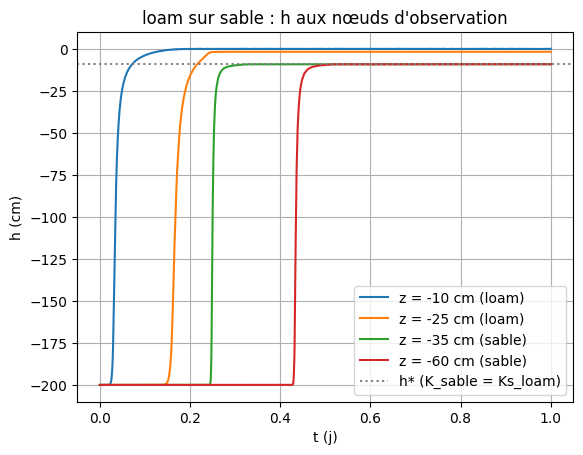

K_sable(h) = Ks_loam = 24.96 cm/j pour h* = -8.97 cm, theta_sable(h*) = 0.237
h à 35 cm (sable) : -9.11 cm à 0,5 j, -9.10 cm à 1 j, theta à 35 cm à 1 j : 0.235


In [23]:
ob_LS = read_obs_node(P_LS)    # colonnes (nœud, variable) : nœuds 11, 26, 36, 61 = 10, 25, 35, 60 cm

# h* : charge de pression à laquelle K du sable égale Ks du loam (racine de K_sable(h) - Ks_loam)
def ecart_K_sable(h):
    return vg_K(h, thr_sable, ths_sable, alpha_sable, n_sable, Ks_sable) - Ks_loam

h_star = brentq(ecart_K_sable, -100, -0.1)
theta_star = vg_theta(h_star, thr_sable, ths_sable, alpha_sable, n_sable)

plt.figure()
plt.plot(ob_LS.index, ob_LS[(11, "h")], "-", label="z = -10 cm (loam)")
plt.plot(ob_LS.index, ob_LS[(26, "h")], "-", label="z = -25 cm (loam)")
plt.plot(ob_LS.index, ob_LS[(36, "h")], "-", label="z = -35 cm (sable)")
plt.plot(ob_LS.index, ob_LS[(61, "h")], "-", label="z = -60 cm (sable)")
plt.axhline(h_star, color="gray", linestyle=":", label="h* (K_sable = Ks_loam)")
plt.ylim(-210, 10)
plt.xlabel("t (j)")
plt.ylabel("h (cm)")
plt.title("loam sur sable : h aux nœuds d'observation")
plt.legend()
plt.grid(True)
plt.show()

h_35_05 = np.interp(0.5, ob_LS.index, ob_LS[(36, "h")])
h_35_1 = np.interp(1.0, ob_LS.index, ob_LS[(36, "h")])
theta_35_1 = nod_LS[1.0]["Moisture"].iloc[35]     # nœud 36 : z = -35 cm
print(f"K_sable(h) = Ks_loam = {Ks_loam} cm/j pour h* = {h_star:.2f} cm, theta_sable(h*) = {theta_star:.3f}")
print(f"h à 35 cm (sable) : {h_35_05:.2f} cm à 0,5 j, {h_35_1:.2f} cm à 1 j, theta à 35 cm à 1 j : {theta_35_1:.3f}")

**Commentaire (instructeur).** Loam sur sable : le front s'arrête à l'interface entre 0,15 et 0,25 j, le temps que $h$ y remonte de −200 à −9 cm ; à cette pression
$K_{sable} = K_{s,loam}$ et le sable évacue les 25 cm/j du loam à gradient unitaire avec $\theta = 0{,}235$ seulement : c'est la
barrière capillaire (le sable est « moins conducteur » que le loam tant qu'il est sec). Le cumul (26,1 cm) est celui du loam seul.
Sable sur loam : le sable se sature en 0,02 j (nappe perchée, $h > 0$ à l'interface), puis le loam contrôle le flux à $K_s$ ; le
cumul (45,1 cm) inclut le stockage de 11,5 cm dans le sable.

## Exercice 4 — Croûte de battance dans HYDRUS-1D  *(≈ 10 min)*

Projets `J07_croute_sans_croute` (loam, 101 nœuds) et `J07_croute_avec_croute` (croûte de 1 cm à $K_s = 0{,}5$ cm/j, 201 nœuds) :
pluie de 10 cm/j pendant 0,5 j, $h_i = -300$ cm, condition atmosphérique avec ruissellement.

1. Tracer `vTop`, `sum(Infil)`, `sum(RunOff)` et `hTop` pour les deux projets ; temps de submersion, infiltration et ruissellement
   totaux, coefficient de ruissellement.
2. Taux d'infiltration stationnaire sous lame d'eau nulle avec croûte ($K_s$ « effective » du système) ; le comparer à $K_s$ du loam.
3. Profils $h(z)$ sur 0–20 cm à 0,25 j (`read_nod_inf`) : pression $h_{sub}$ sous la croûte, gradient de charge à travers la croûte,
   résistance hydraulique $R_c = \Delta H / i$ ; vérifier que $K_{loam}(h_{sub}) < i$ (le sol sous la croûte n'est pas à gradient unitaire).

**Lecture des sorties HYDRUS**

In [24]:
P_sans = f"{HYD}/J07_croute_sans_croute"
P_avec = f"{HYD}/J07_croute_avec_croute"
tl_sans = read_tlevel(P_sans)
tl_avec = read_tlevel(P_avec)
nod_sans = read_nod_inf(P_sans)
nod_avec = read_nod_inf(P_avec)
print(tl_avec[["rTop", "vTop", "hTop", "RunOff", "sum(Infil)", "sum(RunOff)"]].iloc[20:26])

        rTop  vTop    hTop  RunOff  sum(Infil)   sum(RunOff)
Time                                                        
0.0028 -10.0 -10.0 -64.328     0.0    0.028069  1.665300e-08
0.0032 -10.0 -10.0 -54.943     0.0    0.032006  1.665300e-08
0.0036 -10.0 -10.0 -47.050     0.0    0.035943  1.665300e-08
0.0040 -10.0 -10.0 -41.089     0.0    0.039881  1.665300e-08
0.0044 -10.0 -10.0 -35.967     0.0    0.043818  1.665300e-08
0.0048 -10.0 -10.0 -31.878     0.0    0.047755  1.665300e-08


**1a. Taux d'infiltration réel et Ks effective du système**

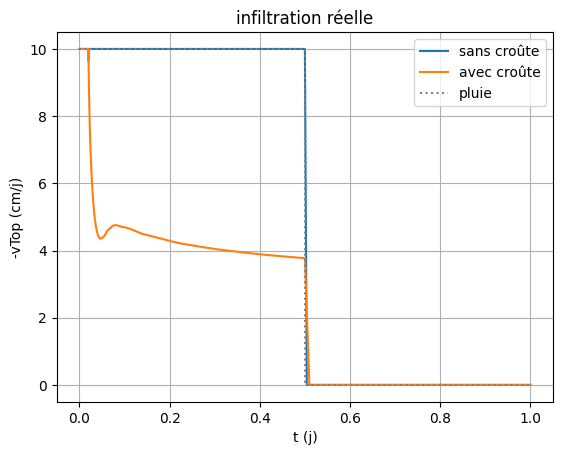

Ks effective du système avec croûte ≈ 4.01 cm/j, soit 0.16 Ks du loam


In [25]:
plt.figure()
plt.plot(tl_sans.index, -tl_sans["vTop"], "-", label="sans croûte")
plt.plot(tl_avec.index, -tl_avec["vTop"], "-", label="avec croûte")
plt.plot([0, 0.5, 0.5, 1], [10, 10, 0, 0], ":", color="gray", label="pluie")
plt.xlabel("t (j)")
plt.ylabel("-vTop (cm/j)")
plt.title("infiltration réelle")
plt.legend()
plt.grid(True)
plt.show()

# taux d'infiltration stationnaire sous lame d'eau nulle : moyenne de -vTop entre 0,2 et 0,5 j
pendant_pluie = tl_avec[(tl_avec.index > 0.2) & (tl_avec.index < 0.5)]
i_stat = -pendant_pluie["vTop"].mean()
print(f"Ks effective du système avec croûte ≈ {i_stat:.2f} cm/j, soit {i_stat / Ks_loam:.2f} Ks du loam")

**1b. Cumuls d'infiltration et de ruissellement**

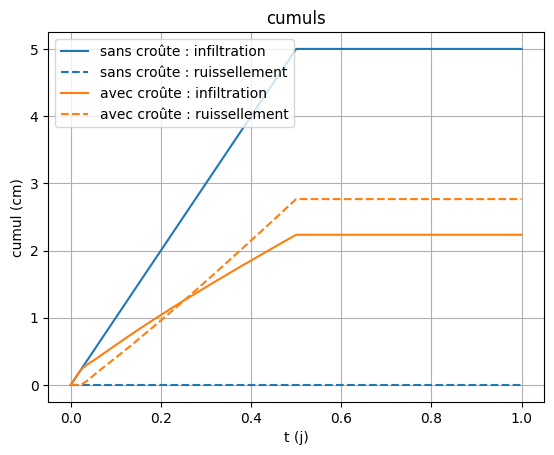

sans croûte : infiltration = 5.00 cm, ruissellement = 0.00 cm, coefficient de ruissellement = 0.00
avec croûte : infiltration = 2.23 cm, ruissellement = 2.77 cm, coefficient de ruissellement = 0.55


In [26]:
plt.figure()
plt.plot(tl_sans.index, tl_sans["sum(Infil)"], "-", color="C0", label="sans croûte : infiltration")
plt.plot(tl_sans.index, tl_sans["sum(RunOff)"], "--", color="C0", label="sans croûte : ruissellement")
plt.plot(tl_avec.index, tl_avec["sum(Infil)"], "-", color="C1", label="avec croûte : infiltration")
plt.plot(tl_avec.index, tl_avec["sum(RunOff)"], "--", color="C1", label="avec croûte : ruissellement")
plt.xlabel("t (j)")
plt.ylabel("cumul (cm)")
plt.title("cumuls")
plt.legend()
plt.grid(True)
plt.show()

pluie_totale = 10.0 * 0.5    # cm
for nom, tl in [("sans croûte", tl_sans), ("avec croûte", tl_avec)]:
    infiltration = tl["sum(Infil)"].iloc[-1]
    ruissellement = tl["sum(RunOff)"].iloc[-1]
    coefficient = ruissellement / pluie_totale
    print(f"{nom} : infiltration = {infiltration:.2f} cm, ruissellement = {ruissellement:.2f} cm, coefficient de ruissellement = {coefficient:.2f}")

**1c. Charge de pression en surface et temps de submersion**

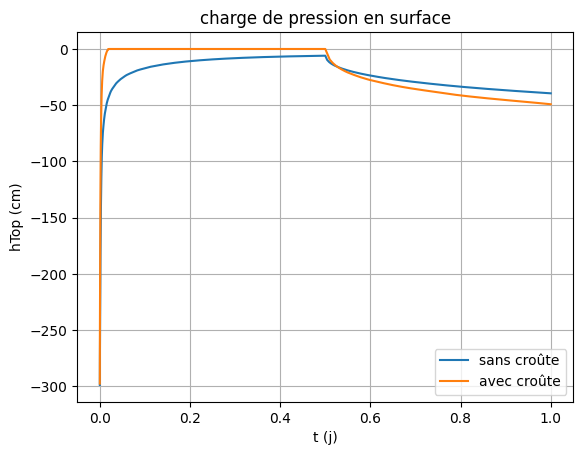

avec croûte : submersion à t = 0.019 j (28 min)
sans croûte : hTop maximal = -6.0 cm, jamais de submersion (10 cm/j < Ks)


In [27]:
plt.figure()
plt.plot(tl_sans.index, tl_sans["hTop"], "-", label="sans croûte")
plt.plot(tl_avec.index, tl_avec["hTop"], "-", label="avec croûte")
plt.xlabel("t (j)")
plt.ylabel("hTop (cm)")
plt.title("charge de pression en surface")
plt.legend()
plt.grid(True)
plt.show()

# temps de submersion : premier instant où hTop atteint 0 (avec croûte) ; sans croûte, hTop reste négatif
submersion_avec = tl_avec[tl_avec["hTop"] >= -1e-6]
t_p_avec = submersion_avec.index[0]
hTop_max_sans = tl_sans["hTop"].max()
print(f"avec croûte : submersion à t = {t_p_avec:.3f} j ({t_p_avec * 24 * 60:.0f} min)")
print(f"sans croûte : hTop maximal = {hTop_max_sans:.1f} cm, jamais de submersion (10 cm/j < Ks)")

**3a. Profils h(z) près de la surface à 0,25 j**

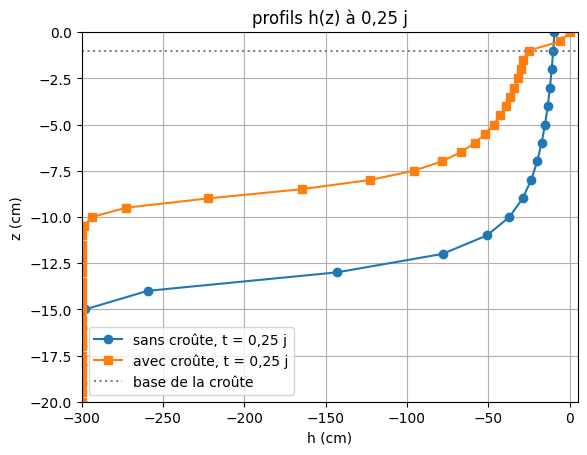

In [28]:
plt.figure()
plt.plot(nod_sans[0.25]["Head"], nod_sans[0.25]["Depth"], "o-", label="sans croûte, t = 0,25 j")
plt.plot(nod_avec[0.25]["Head"], nod_avec[0.25]["Depth"], "s-", label="avec croûte, t = 0,25 j")
plt.axhline(-1, color="gray", linestyle=":", label="base de la croûte")
plt.xlim(-300, 5)
plt.ylim(-20, 0)
plt.xlabel("h (cm)")
plt.ylabel("z (cm)")
plt.title("profils h(z) à 0,25 j")
plt.legend()
plt.grid(True)
plt.show()

**3b. Résistance hydraulique de la croûte**

In [29]:
profil_avec = nod_avec[0.25]
h_sub = profil_avec["Head"].iloc[2]      # nœud 3 : z = -1 cm, base de la croûte (dz = 0,5 cm)

# charge hydraulique H = h + z en surface (h = 0, z = 0) et à la base de la croûte (z = -1 cm)
H_surface = 0.0 + 0.0
H_base = h_sub + (-1.0)
dH = H_surface - H_base
gradient = dH / 1.0                      # épaisseur de la croûte : 1 cm

# flux à travers la croûte à 0,25 j : moyenne de -vTop entre 0,24 et 0,26 j
autour = tl_avec[(tl_avec.index > 0.24) & (tl_avec.index < 0.26)]
i_025 = -autour["vTop"].mean()

# résistance hydraulique de la croûte et conductivité moyenne équivalente
R_c = dH / i_025
K_c = 1.0 / R_c
K_loam_sub = vg_K(h_sub, thr_loam, ths_loam, alpha_loam, n_loam, Ks_loam)

print(f"t = 0,25 j : h sous la croûte = {h_sub:.1f} cm, gradient de charge à travers la croûte = {gradient:.1f}")
print(f"i = {i_025:.2f} cm/j, résistance R_c = dH / i = {R_c:.2f} j, K_c moyen = 1 cm / R_c = {K_c:.3f} cm/j")
print(f"K_loam(h_sub) = {K_loam_sub:.2f} cm/j < i : le loam sous la croûte est à gradient > 1 (front encore proche)")

t = 0,25 j : h sous la croûte = -25.2 cm, gradient de charge à travers la croûte = 26.2
i = 4.15 cm/j, résistance R_c = dH / i = 6.30 j, K_c moyen = 1 cm / R_c = 0.159 cm/j
K_loam(h_sub) = 1.31 cm/j < i : le loam sous la croûte est à gradient > 1 (front encore proche)


**Commentaire (instructeur).** Sans croûte, 10 cm/j $< K_s$ : tout s'infiltre et la surface reste non saturée ($h \approx -6$ cm à 0,5 j). Avec une croûte de 1 cm
à $K_s/50$, la submersion survient après 28 min et le taux d'infiltration tombe à $\approx 4$ cm/j : 55 % de la pluie ruisselle.
La croûte n'est même pas saturée sur toute son épaisseur ($h$ passe de 0 à −25 cm en 1 cm, gradient 26) : sa conductivité moyenne
effective (0,16 cm/j) est inférieure à son $K_s$. Le loam sous-jacent reste à $h \approx -25$ cm, non saturé, avec un gradient encore
supérieur à 1 pendant la pluie ; il se redistribue ensuite lentement.

## Exercice 5 — Bonus — Green–Ampt à deux couches (sable sur loam)  *(≈ facultatif)*

Généraliser Green–Ampt à un profil à deux couches (Childs & Bybordi 1969) : quand le front est dans la couche 2 (profondeur $L_f > L_1$),
la conductivité effective en série est $K_{eff} = L_f/[L_1/K_1 + (L_f - L_1)/K_2]$ et $i = K_{eff}(|h_{f,2}| + L_f)/L_f$ (lame nulle).
Le front avance de $dL$ en un temps $dt = \Delta\theta\,dL/i$ : faire avancer le front pas à pas (boucle sur $L$) pour sable (30 cm)
sur loam, $h_i = -200$ cm, et comparer $I(t)$ à `J07_stratifie_sable_sur_loam` (45,1 cm à 1 j). Pourquoi le cas loam sur sable
ne se traite-t-il pas ainsi ?

**Paramètres de Green–Ampt des deux couches (h_i = −200 cm)**

In [30]:
L1 = 30.0        # épaisseur du sable (cm)
h_i = -200.0

dtheta_sable = ths_sable - vg_theta(h_i, thr_sable, ths_sable, alpha_sable, n_sable)
dtheta_loam2 = ths_loam - vg_theta(h_i, thr_loam, ths_loam, alpha_loam, n_loam)
h_grid2 = np.linspace(h_i, 0, 2001)
hf_sable = np.trapezoid(vg_K(h_grid2, thr_sable, ths_sable, alpha_sable, n_sable, Ks_sable) / Ks_sable, h_grid2)
hf_loam2 = np.trapezoid(vg_K(h_grid2, thr_loam, ths_loam, alpha_loam, n_loam, Ks_loam) / Ks_loam, h_grid2)
print(f"sable : dtheta = {dtheta_sable:.3f}, |h_f| = {hf_sable:.2f} cm / loam : dtheta = {dtheta_loam2:.3f}, |h_f| = {hf_loam2:.2f} cm")

sable : dtheta = 0.384, |h_f| = 3.81 cm / loam : dtheta = 0.237, |h_f| = 6.91 cm


**Avancée du front pas à pas et comparaison à HYDRUS**

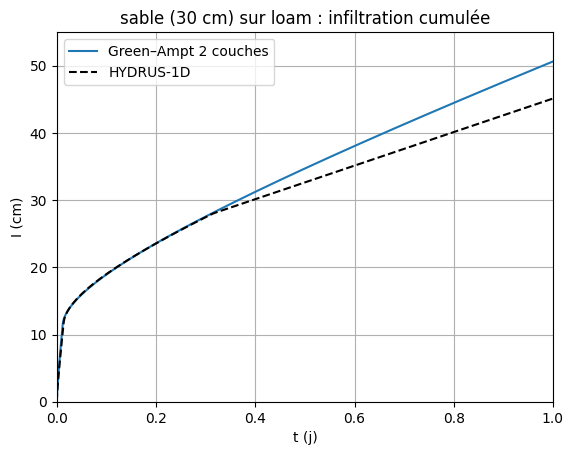

front à l'interface à t = 0.0117 j (Green–Ampt), I(1 j) = 50.6 cm (Green–Ampt) contre 45.1 cm (HYDRUS)


In [31]:
# le front avance de dL à chaque pas ; le temps nécessaire est dt = dtheta * dL / i(L)
dL = 0.05
L = 0.0
t = 0.0
L_2c = [0.0]
t_2c = [0.0]
I_2c = [0.0]
for k in range(6000):
    L = L + dL
    if L <= L1:
        i = Ks_sable * (hf_sable + L) / L
        dtheta = dtheta_sable
        I = L * dtheta_sable
    else:
        K_eff = L / (L1 / Ks_sable + (L - L1) / Ks_loam)
        i = K_eff * (hf_loam2 + L) / L
        dtheta = dtheta_loam2
        I = L1 * dtheta_sable + (L - L1) * dtheta_loam2
    t = t + dtheta * dL / i
    L_2c.append(L)
    t_2c.append(t)
    I_2c.append(I)

plt.figure()
plt.plot(t_2c, I_2c, "-", label="Green–Ampt 2 couches")
plt.plot(tl_SL.index, tl_SL["sum(Infil)"], "k--", label="HYDRUS-1D")
plt.xlim(0, 1)
plt.ylim(0, 55)
plt.xlabel("t (j)")
plt.ylabel("I (cm)")
plt.title("sable (30 cm) sur loam : infiltration cumulée")
plt.legend()
plt.grid(True)
plt.show()

t_interface = np.interp(L1, L_2c, t_2c)
I_1j = np.interp(1.0, t_2c, I_2c)
print(f"front à l'interface à t = {t_interface:.4f} j (Green–Ampt), I(1 j) = {I_1j:.1f} cm (Green–Ampt) contre {I_SL:.1f} cm (HYDRUS)")

**Commentaire (instructeur).** Pour le sable sur loam, le modèle piston à deux couches capture l'essentiel : le sable se remplit en un centième de jour puis le
loam limite le flux, qui tend vers $K_{s,loam}$ ; le cumul à 1 j est surestimé de 12 % (50,6 contre 45,1 cm), car $|h_f|$ du loam
($\int K_r\,dh$ = 7 cm) est trop grand pour ce sol à front diffus (voir exercice 1). Le cas loam sur sable ne se traite pas
ainsi : le sable n'est jamais saturé (il transmet le flux à $h \approx -9$ cm et $\theta = 0{,}235$), ce qui contredit l'hypothèse de
piston saturé ; il faut remplacer $h_f$ du sable par sa pression d'entrée d'eau et $\Delta\theta$ par $\theta(-9) - \theta_i$, ou
simplement utiliser Richards.

## Pour aller plus loin

* Avec le solveur de Richards du Jour 6 (paramètres par nœud), reproduire `J07_stratifie_loam_sur_sable` et tester l'effet de $\Delta z$ à l'interface.
* Ajuster Green–Ampt ($K_s$, $h_f$) sur les courbes du double anneau et comparer $S = \sqrt{2 K_s |h_f| \Delta\theta}$ au $S$ de Philip.
* Calculer la lame ruisselée SCS-CN d'une pluie de 60 mm pour $CN$ = 60, 78, 90 et la comparer au ruissellement Green–Ampt (ex. 1) pour la même pluie en 1 h, 3 h et 12 h.